#Customer segmentation with clustering project

# Technical Stack

Python | pandas | NumPy | scikit-learn | matplotlib | seaborn | PCA | t-SNE | K-Means | Jupyter Notebook

# Introduction

This project explores customer segmentation using unsupervised machine learning techniques in Python. The analysis focuses on identifying meaningful behavioural patterns within customer data to support data-driven decision-making and targeted business strategies.

# Business Context

Organisations increasingly rely on customer analytics to better understand user behaviour, improve engagement, and optimise services. Clustering techniques such as K-Means can help uncover hidden structures within data, enabling more effective segmentation and personalised approaches.

# Objectives

* Perform exploratory data analysis on customer data
* Prepare and transform features for machine learning
* Apply clustering techniques including K-Means
* Evaluate cluster quality using quantitative metrics
* Use dimensionality reduction techniques such as PCA and t-SNE for visualisation
* Generate interpretable insights from customer segments



> **Disclaimer**
>
> Note that although a real-life data set was provided, the business context in this project is fictitious. Any resemblance to companies and persons (living or dead) is coincidental. The course designers and hosts assume no responsibility or liability for any errors or omissions in the content of the business context and data sets. The information in the data sets is provided on an 'as is' basis, with no guarantees of completeness, accuracy, usefulness, or timeliness.

<br></br>



In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv(
    "https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip"
)

# First checks
print(data.shape)
display(data.head())
print(data.info())

# Missing values
print("\nMissing values:")
print(data.isnull().sum().sort_values(ascending=False))

# Duplicate rows
print("\nDuplicate rows:", data.duplicated().sum())

(951669, 20)


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 951669 entries, 0 to 951668
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Quantity              951669 non-null  int64 
 1   City                  951534 non-null  object
 2   Continent             951669 non-null  object
 3   Postal_Code           947953 non-null  object
 4   State_Province        834477 non-null  object
 5   Order_Date            951669 non-null  object
 6   Delivery_Date         951669 non-null  object
 7   Total Revenue         951669 non-null  object
 8   Unit Cost             951669 non-null  object
 9   Discount              951669 non-null  object
 10  OrderTypeLabel        951669 non-null  object
 11  CustomerCountryLabel  951669 non-null  object
 12  Customer_BirthDate    951669 non-null  object
 13  Customer_Group        951669 non-null  object
 14  Customer_Type         951669 non-null  object
 15  Order ID         

Upon initial inspection of the Data, I can see that there are 21 duplicate rows.

And the following missing values:

*   State_Province          117192
*   Postal_Code               3716
*   City                       135

These are not key to the features listed for clustering by the Mini-Project, and so I could ignore this and only look at it later in the descriptive analysis later (where I can say that a customers within a certain cluster come from X state, etc).

Required Metrics for Project:
* Frequency
* Recency
* CLV
* Average unit cost
* Customer age

There are also problems with formatting of features like dates and ages that are not going to work well in their current state.
Due to this, I will do the following:

*   Remove exact duplicate rows.
*   Convert the columns I need into usable formats (the date and currency formats are Objects/Strings and not suitable at the moment).
*   Inspect whether one order appears across multiple product rows.







In [ ]:
# Remove exact duplicate rows
data = data.drop_duplicates()

print("New shape:", data.shape)
print("Remaining duplicate rows:", data.duplicated().sum()) #confirm no duplicates remain

New shape: (951648, 20)
Remaining duplicate rows: 0


Next I will convert the Dates to a DateTime data type.

In [ ]:
#Convert the date features to an actual datetime format
data["Order_Date"] = pd.to_datetime(data["Order_Date"], format="%d%b%Y")
data["Delivery_Date"] = pd.to_datetime(data["Delivery_Date"], format="%d%b%Y")
data["Customer_BirthDate"] = pd.to_datetime(data["Customer_BirthDate"], format="%d%b%Y")

#Check the data types are now correct and the format looks correct
display(data.head())
print(data.info())


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,$28.50,$9.10,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,$113.40,$56.90,.,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,$41.00,$18.50,.,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,2012-01-01,2012-01-03,$35.20,$29.60,.,Internet Sale,Australia,1997-06-22,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,2012-01-01,2012-01-04,$24.70,$23.60,.,Internet Sale,Canada,1978-01-28,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


<class 'pandas.core.frame.DataFrame'>
Index: 951648 entries, 0 to 951668
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Quantity              951648 non-null  int64         
 1   City                  951513 non-null  object        
 2   Continent             951648 non-null  object        
 3   Postal_Code           947932 non-null  object        
 4   State_Province        834456 non-null  object        
 5   Order_Date            951648 non-null  datetime64[ns]
 6   Delivery_Date         951648 non-null  datetime64[ns]
 7   Total Revenue         951648 non-null  object        
 8   Unit Cost             951648 non-null  object        
 9   Discount              951648 non-null  object        
 10  OrderTypeLabel        951648 non-null  object        
 11  CustomerCountryLabel  951648 non-null  object        
 12  Customer_BirthDate    951648 non-null  datetime64[ns]
 13  Cust

Next I will make sure the currency featrures are consistent. I learned that the decimal numbers in brackets in the data tables above show that the number is actually negative, so I have taken this into account to ensure I turn them into -0.45 from (0.45).

In [ ]:
# Function to clean money/currency columns, can use again later if needed
def clean_money(col):
    col = col.replace(r'[\$,]', '', regex=True)         # remove $ and commas ... added 'r' to make it raw and avoid the \ syntax problem
    col = col.replace(r'\((.*?)\)', r'-\1', regex=True) # (x) → -x
    return pd.to_numeric(col)

# Apply to relevant columns
data["Total Revenue"] = clean_money(data["Total Revenue"])
data["Unit Cost"] = clean_money(data["Unit Cost"])
data["Profit"] = clean_money(data["Profit"])

#Check it is all working as it should
print(data[["Total Revenue", "Unit Cost", "Profit"]].head())
print(data[["Total Revenue", "Unit Cost", "Profit"]].dtypes)

   Total Revenue  Unit Cost  Profit
0           28.5        9.1     1.2
1          113.4       56.9    -0.4
2           41.0       18.5     4.0
3           35.2       29.6     5.6
4           24.7       23.6     1.1
Total Revenue    float64
Unit Cost        float64
Profit           float64
dtype: object


# Feature Creation
Everything looks good so now I will create our new features. This starts with grouping, so I will look at an example customer and also check for Unique Customer IDs so I can see how much we can consolidate the data set.

In [ ]:
# Look at one customer's data
example_customer = data[data["Customer ID"] == data["Customer ID"].iloc[0]]

display(example_customer.head())
print("Rows for this customer:", example_customer.shape[0])

# How many unique customers do we have?
display("unique Customer IDs: ", data["Customer ID"].nunique())

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,1.2,6,99,8818
474,2,Leinster,Oceania,6437,Western Australia,2012-01-03,2012-01-09,99.0,49.7,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230011283,-0.4,6,99,8818
475,3,Leinster,Oceania,6437,Western Australia,2012-01-03,2012-01-09,189.3,57.4,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230011283,17.1,6,99,8818
22618,2,Leinster,Oceania,6437,Western Australia,2012-02-28,2012-03-05,24.6,10.4,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230320300,3.8,6,99,8818
22619,2,Leinster,Oceania,6437,Western Australia,2012-02-28,2012-03-05,25.8,10.9,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230320300,4.0,6,99,8818


Rows for this customer: 31


'unique Customer IDs: '

68300

It looks like there are 68300 unique customer ID's, and I can see that from the example customer the oder numbers are unique, and the descriptive data remains the same.

In [ ]:

#Establish the reference date, which will be the most recent order from all data
reference_date = data["Order_Date"].max()
print(reference_date)

#Create the new DF that will hold the new features
customer_df = (
    data.groupby("Customer ID").agg(
        frequency=("Order ID", "nunique"),
        last_order_date=("Order_Date", "max"),
        clv=("Total Revenue", "sum"),
        avg_unit_cost=("Unit Cost", "mean"),
        birthdate=("Customer_BirthDate", "first")
    ).reset_index()
)

# Recency (days since last purchase)
customer_df["recency"] = (reference_date - customer_df["last_order_date"]).dt.days

# Customer age (in years as a decimal for better accuracy in K-means later)
customer_df["customer_age"] = (
    (reference_date - customer_df["birthdate"]).dt.days / 365.25
).round(1)


#Create the final DF of the final correct features with Recency and Age determined
customer_features = customer_df[
    ["Customer ID", "frequency", "recency", "clv", "avg_unit_cost", "customer_age"]
]

display(customer_features.head())
print(customer_features.shape)

2016-12-30 00:00:00


,Customer ID,frequency,recency,clv,avg_unit_cost,customer_age
0,1,28,17,4322.70,89.622857,63.1
1,3,14,124,2821.00,90.505000,33.5
2,4,8,1108,782.67,37.195556,33.5
3,5,15,5,2810.98,107.947368,28.5
4,6,13,192,1604.58,52.526667,58.0


(68300, 6)


After creating the final DF called customer_features that holds the data with the correct new features, checking the values it all looks good. I chose to use a decimal for the age rather than an int just because it would be more accurate for clustering and further evaluation.

Next I will apply scaling to the data so taht clustering isn't dominated by the higher values.

# **Scaling**



In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features (exclude Customer ID)
features = ["frequency", "recency", "clv", "avg_unit_cost", "customer_age"]

X = customer_features[features]

# Initialise scaler
scaler = StandardScaler()

# Fit and transform
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (important for readability)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

display(X_scaled_df.head())

X_scaled_df.describe().round(2)

,frequency,recency,clv,avg_unit_cost,customer_age
0,1.943794,-0.845972,1.379468,0.282257,1.115585
1,0.347624,-0.587834,0.506337,0.305469,-0.578298
2,-0.336449,1.786063,-0.678804,-1.097228,-0.578298
3,0.461636,-0.874922,0.500511,0.764418,-0.864427
4,0.233611,-0.423785,-0.200923,-0.693830,0.823734


,frequency,recency,clv,avg_unit_cost,customer_age
count,68300.00,68300.00,68300.00,68300.00,68300.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.13,-0.89,-1.13,-2.06,-1.41
25%,-0.68,-0.78,-0.73,-0.56,-0.88
50%,-0.22,-0.43,-0.26,-0.14,-0.01
75%,0.46,0.41,0.44,0.36,0.86
max,10.27,3.51,9.83,36.43,1.74


Standardisation/Scaling was successful, as all transformed features have means approximately equal to 0 and standard deviations approximately equal to 1. The displayed value of -0.00 for one mean (clv) is due to floating-point rounding and is not going to cause any issues moving forward from what I can see.

Next I am going to choose the number of clusters I will be using by applying the Elbow and Silhouette methods.

# **Elbow and Silhouette Methods**

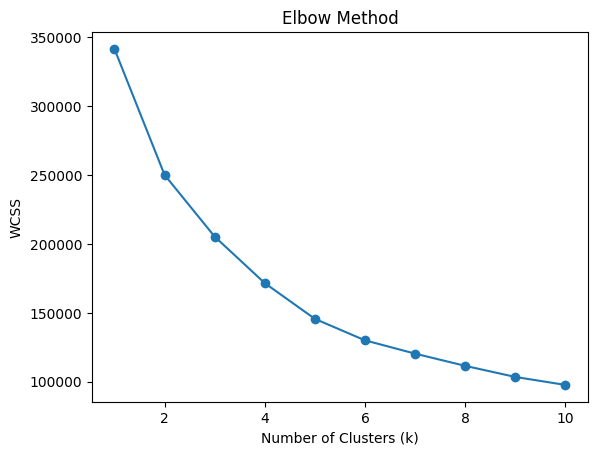

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

The Elbow plot does not show a sharply defined elbow; however, a noticeable reduction in WCSS is observed up to k = 4 or 5, perhaps 6 could also be argued, after which the rate of change slows and becomes practically linear. This suggests that adding more clusters beyond this point will not improve future output.

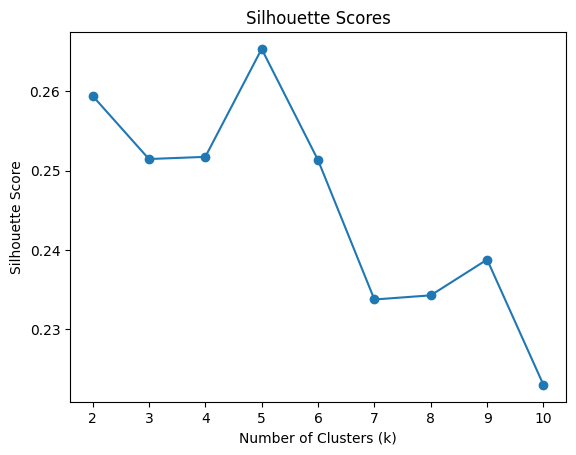

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):  # must start at 2
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels)
    silhouette_scores.append(score)

# Plot
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

The Silhouette analysis shows that k = 5 yields the highest score, indicating the best balance. While k = 2 also produces a relatively high score, it may oversimplify the customer segments in to A/B which I don't think is really ideal based on my observations of the original data set descriptors.

Based on both the Elbow method and Silhouette analysis, k = 5 is what I will select as the optimal number of clusters. The Elbow method was not as clear as desired, but in partnership with the Silhoutte method, it would seem to confirm that k = 5 would be the best selection.

Next I will run k-means with k being set to 5.

# **K-Means**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans

# Fit KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_df)

# Make a safe copy (I got an error message the first time running)
customer_features = customer_features.copy()

# Add cluster labels
customer_features["cluster"] = cluster_labels

# Check output
display(customer_features.head())
print(customer_features["cluster"].value_counts().sort_index())

,Customer ID,frequency,recency,clv,avg_unit_cost,customer_age,cluster
0,1,28,17,4322.70,89.622857,63.1,1
1,3,14,124,2821.00,90.505000,33.5,4
2,4,8,1108,782.67,37.195556,33.5,0
3,5,15,5,2810.98,107.947368,28.5,4
4,6,13,192,1604.58,52.526667,58.0,2


cluster
0    10663
1    11260
2    20069
3     3780
4    22528
Name: count, dtype: int64


The cluster sizes are uneven but reasonable, with all clusters containing a substantial number of customers. One cluster (3) is notably smaller, suggesting it may represent a more specialised or distinctly unique customer group.

Now I want to better understand each cluster, and I will focus particularly on 3. But I will look for patterns that might help me identify the group's unique complexion, such as:

* Higher frequency = buys more often
* Lower recency = bought more recently, so more “active” or recently engaged
* Higher CLV = more valuable overall
* Higher avg_unit_cost = tends to buy more expensive items
* Higher customer_age = older customer segment

So I might see something like
* High frequency + low recency (ordered something recently) = loyal active customers
* High CLV + high unit cost = premium customers
* Low frequency + high recency (last ordered a while ago) = inactive customers

In [ ]:
cluster_summary = customer_features.groupby("cluster")[
    ["frequency", "recency", "clv", "avg_unit_cost", "customer_age"]
].mean()

display(cluster_summary)

,frequency,recency,clv,avg_unit_cost,customer_age
cluster,,,,,
0,4.022695,1114.240927,611.233535,63.702953,48.029298
1,25.788632,120.906217,4897.457106,82.722926,39.403952
2,8.774877,225.583437,1413.638161,70.988890,60.260237
3,4.315344,573.260582,1581.301484,180.755410,45.054365
4,9.866122,229.696911,1650.593174,74.126347,28.531863


Next I will create a heatmap after standardising the data so I can visualise the difference between the clusters more clearly.

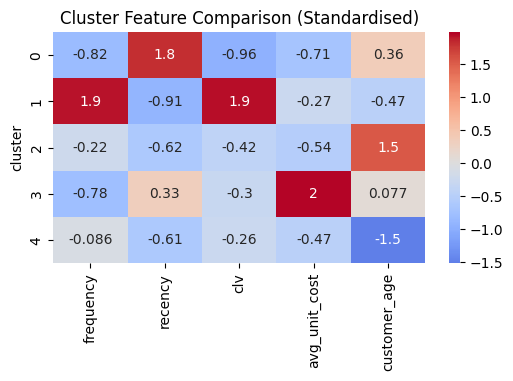

In [ ]:
# Scale the summary (important!)
scaler = StandardScaler()
cluster_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_summary),
    index=cluster_summary.index,
    columns=cluster_summary.columns
)

# Plot heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(cluster_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Cluster Feature Comparison (Standardised)")
plt.show()

Just interpretting the output based on the types of things I am looking for in the previous text box, I can see the following:
* Cluster 0: The Inactive and low value customer segment, but have the highest recency score (meaning last purchase was a while ago on average). Need to watch for Churn risk.
* Cluster 1: Probably Higher Value or Premium Customers, buying regularly.
* Cluster 2: The reliable customer segment, nothing outstanding but consistent and made up of the oldest customers.
* Cluster 3: Is strange, as they have somehwat high recency scores, but have the highest unit value cost. I could interpret this as being customers that buy big 'one-off' purchases.
* Cluster 4: Looks like a younger and more active cluster of customers, but not the most active group.

Next I will perform boxplot visualisation to ensuyre that I see the distribution within each of the clusters, as the Means will not show the variation within.

/tmp/ipykernel_711/2323177028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_711/2323177028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_711/2323177028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_711/2323177028.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_711/2323177028.py:11: FutureWarning: 

Passin

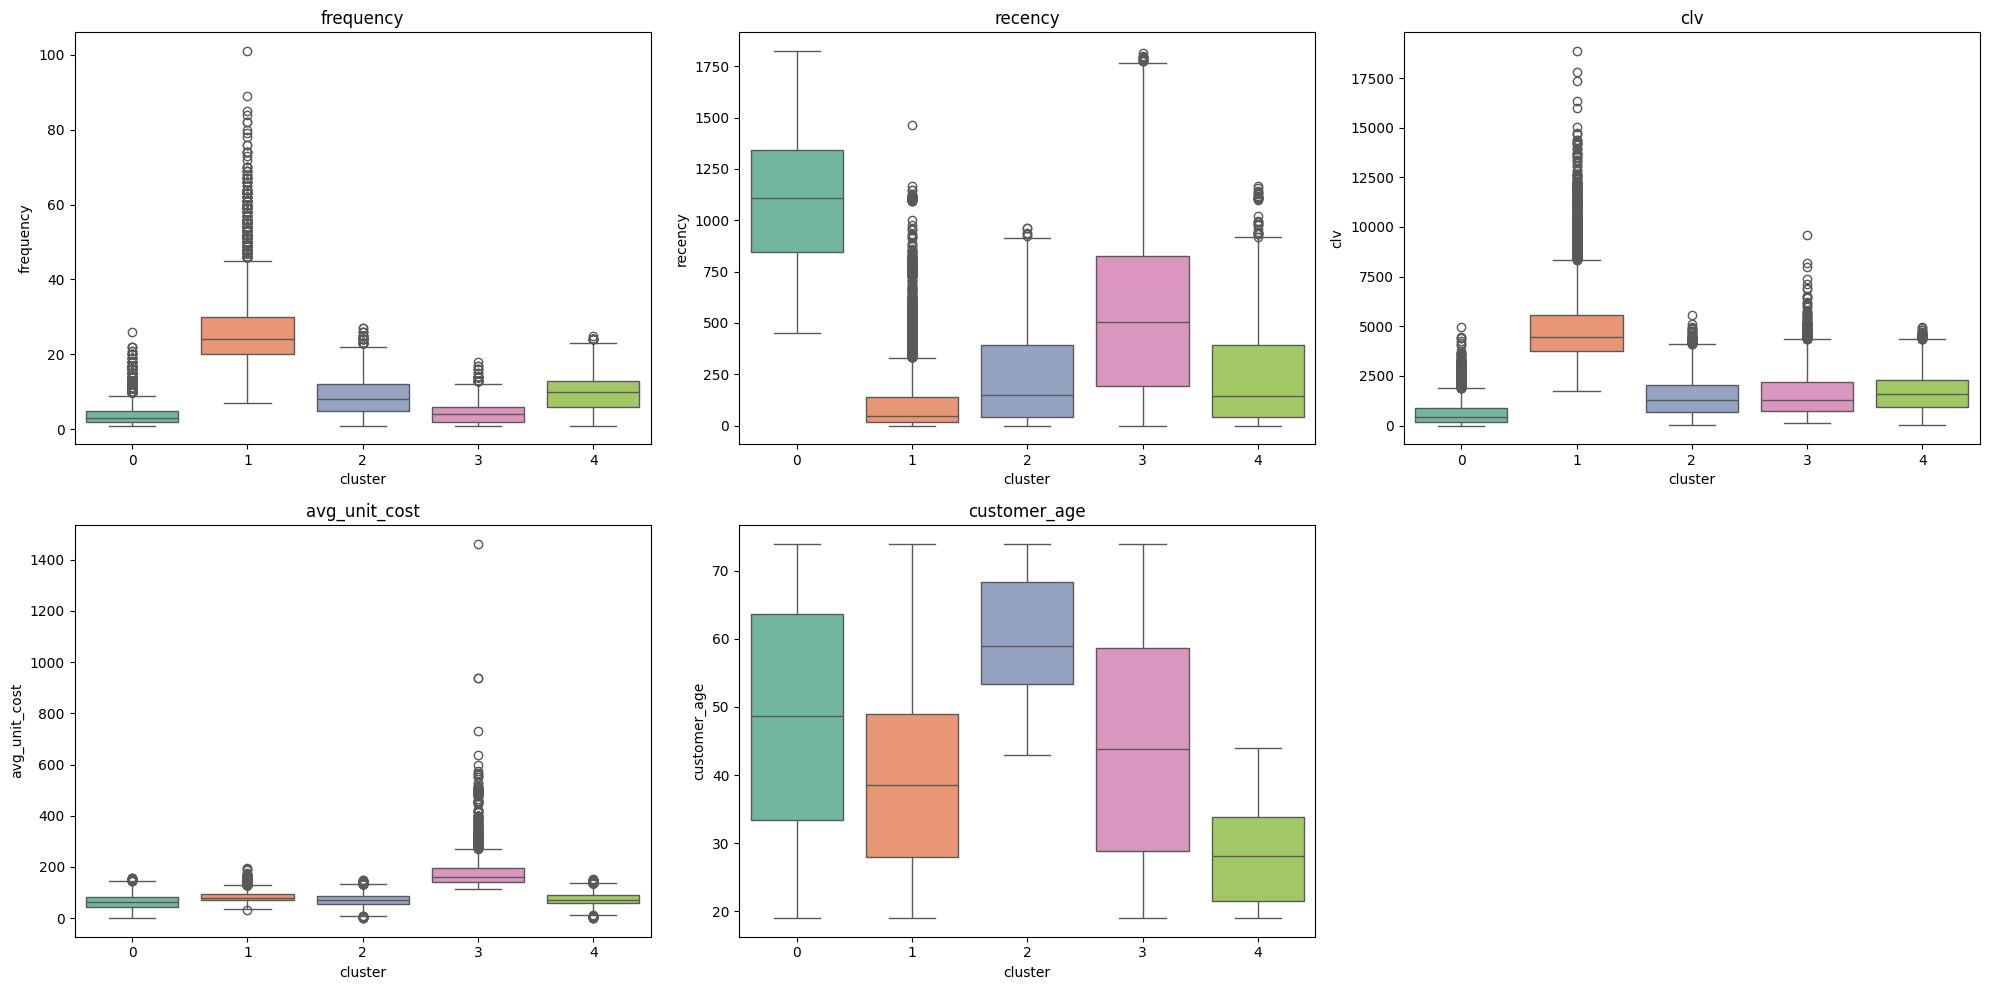

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["frequency", "recency", "clv", "avg_unit_cost", "customer_age"]

# Create grid: 2 rows × 3 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        x="cluster",
        y=feature,
        data=customer_features,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(feature)

# Remove empty subplot (since we have 5 plots but 6 spaces)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

The boxplots confirm clear differences between clusters across the features. Cluster 1 is characterised by high frequency and CLV with low recency, indicating highly active and valuable customers. Cluster 1 also shows a low median recency, indicating recent activity, but also contains several higher-value outliers, suggesting some variability in engagement within the cluster. Cluster 0 exhibits low frequency and high recency, suggesting inactive or dormant customers. Cluster 3 is distinct due to significantly higher average unit cost, indicating a premium purchasing segment, although these customers are less active. Clusters 2 and 4 show moderate purchasing behaviour, with age differentiating them, as Cluster 2 represents older customers and Cluster 4 younger customers. Some variability and outliers are observed within clusters, indicating 'heterogeneity' in customer behaviour.

Now I want to see if these customers actually separate well. To do this I will use PCA and t-SNE.

# **PCA**

In [ ]:
from sklearn.decomposition import PCA

# Create PCA object (all components)
pca = PCA()

# Fit PCA
pca.fit(X_scaled_df)

# Explained variance
explained_variance = pca.explained_variance_ratio_

# Create table
explained_variance_table = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance': explained_variance
}).round(3)

explained_variance_table["Cumulative Variance"] = explained_variance_table["Explained Variance"].cumsum()

display(explained_variance_table)


,Component,Explained Variance,Cumulative Variance
0,PC1,0.443,0.443
1,PC2,0.208,0.651
2,PC3,0.191,0.842
3,PC4,0.141,0.983
4,PC5,0.017,1.000


Interestingly, most of the structure in the data is already captured by PC1 to PC4, so PC5 doesn't add much.
The good news for me is that PC1 and PC2 together explain 65% of total variance which means that running 2D PCA will likely visualise the clusters well.

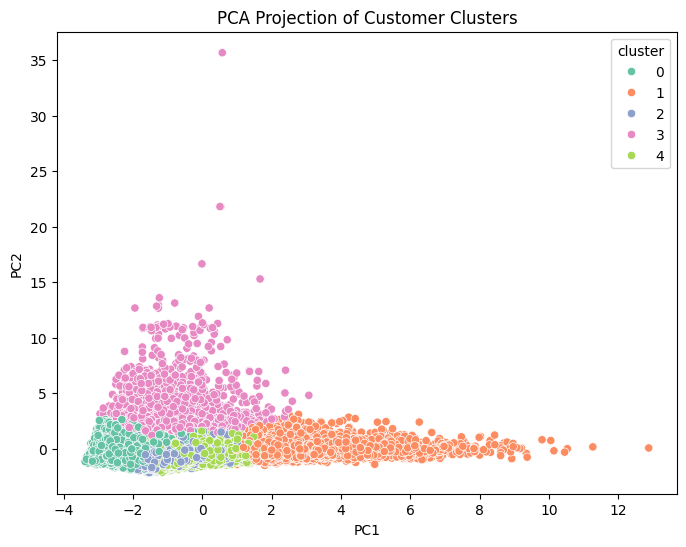

In [ ]:
from sklearn.decomposition import PCA

# PCA with 2 components
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled_df)

# Create DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster"] = customer_features["cluster"]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster", palette="Set2")
plt.title("PCA Projection of Customer Clusters")
plt.show()

The PCA plot shows that some clusters, particularly Cluster 1, are clearly separated, indicating distinct customer behaviour. Cluster 3 also exhibits some separation, likely driven by differences in average unit cost. However, Clusters 2 and 4 show significant overlap, suggesting that these customer groups have more similar behavioural characteristics.

This indicates that while clustering identifies meaningful segments, some groups (2 & 4) are less distinct when projected into two dimensions.

I would also suggest that the PCA visualisation doesn't fully capture the full variation of the clusters with just PC1 and 2. Visualising in 3D might allow a clearer view of how these clusters interact with 84% variance explained with PC1,2 and 3.

Now I will run t-SNE to try and see the differences between the overlapping clusters.

# t-SNE

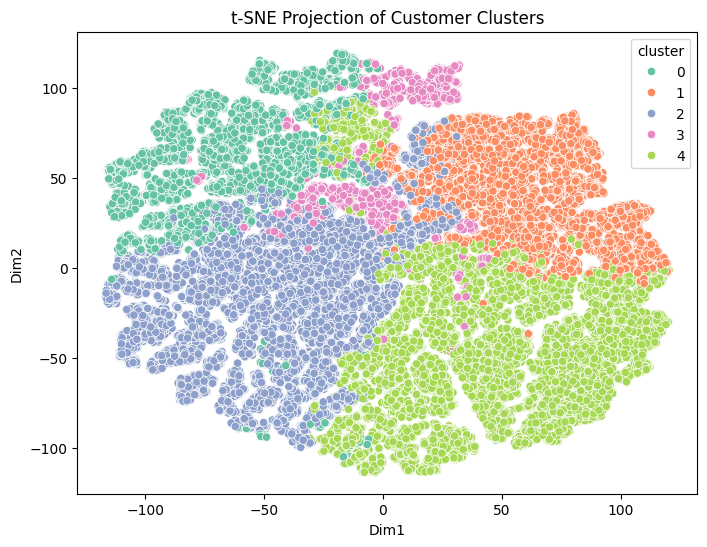

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_scaled_df)

tsne_df = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
tsne_df["cluster"] = customer_features["cluster"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="Dim1", y="Dim2", hue="cluster", palette="Set2")
plt.title("t-SNE Projection of Customer Clusters")
plt.show()

t-SNE was considerably more computationally intensive than PCA due to the size of the customer dataset. This is consistent with the known limitations of t-SNE on large datasets.

I used perplexity 30 as this is a pretty standard choice for a data set of this size. The output reaffirms that this was a good choice as it is readable.

t-SNE works by separating clusters that differ over multiple dimensions, so although Cluster 3 looks a little less clearly separated, this can be explained by the fact that the average unit cost is the main distinguishing feature for it, the other features are less distinct.

I can see that there are distinct clusters but there is overlap. The seemingly random pocket of cluster 4 in the higher area of Dim2 can be explained by being a 'projection artefact'. This is a side effect of the 2D visualising process and it is still a distinct group.



# **Conclusions**

# Key Business Insights:

Cluster 1 seems to represent the largest proportion of value for the business. There are a premium group of customers who are not very active but they purchase larger high value products. Because of the separation in age between cluster 2 and 4, I would also suggest that some targetted marketting would be possible based on age, and customers with limited activity could be targetted to encourage more engagement.

# Limitations of the analysis:

It's clear to see that the clusters are not totally distinct and unique, with overlap ocurring in certain areas. Ultimately, customers are complex and this is reflected in the data.
The results are also based on the features that were determined by the mini-project, so there could be other features that could be identified or engineered that might allow us to identify more distinct clusters.

PCA and t-SNE had their own weaknesses; PCA couldn't show all variablity in 2D, and t-SNE's output means that the actual distance between the clusters are not actually meaningful compared to PCA, which is why I saw that Cluster 4 had an unexpected visualisation to me, but it didn't mean there was any problem as PCA captured what t-SNE didn't.  

# General Summary

I think that we did find meaningful customer segments, with justification for their separation. The features chosen were likely to be a good choice but further thought could be given to features moving forward.

Combining the k-Means, PCA, and t-SNE methods gave me far better coverage to visualise and interpret the data.

The business can use the descriptive features of the larger data set to also see if these clusters have descriptive features in common (does cluster 3 live in a specific geographic area) which would inform more business decisions.

### Reference:
SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].